<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# Simple Linear Regression

Estimated time needed: **15** minutes
    

## Objectives

After completing this lab, you will be able to:

* Use scikit-learn to implement simple linear regression
* Create, train, and test a linear regression model on real data


### Import needed packages


For this lab, you will need to have the following packages:
 - NumPy
 - Matplotlib
 - Pandas
 - Scikit-learn

To avoid issues importing these libraries, you may execute the following cell to ensure they are available.


In [ ]:
!pip install numpy==2.2.0
!pip install pandas==2.2.3
!pip install scikit-learn==1.6.0
!pip install matplotlib==3.9.3

Now, you can import these libraries.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

## Load the data
The dataset you will use resides at the following URL. You can use the URL directly with the Pandas library to load the dataset.


In [2]:
url= "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv"

In [3]:
df=pd.read_csv(url)

In [4]:
# verify successful load with some randomly selected records
df.sample(5)

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
795,2014,MINI,COOPER S CONVERTIBLE,MINICOMPACT,1.6,4,M6,Z,9.1,6.7,8.0,35,184
1027,2014,VOLKSWAGEN,CC,COMPACT,2.0,4,M6,Z,11.6,7.7,9.8,29,225
990,2014,TOYOTA,RAV4,SUV - SMALL,2.5,4,AS6,X,10.0,7.6,8.9,32,205
123,2014,BMW,M6 CABRIOLET,SUBCOMPACT,4.4,8,M6,Z,16.2,10.9,13.8,20,317
870,2014,PORSCHE,911 CARRERA 4 CABRIOLET,MINICOMPACT,3.4,6,M7,Z,12.6,9.0,11.0,26,253



## Understand the data

### `FuelConsumption.csv`:
You will use a fuel consumption dataset, **`FuelConsumption.csv`**, which contains model-specific fuel consumption ratings and estimated carbon dioxide emissions for new light-duty vehicles for retail sale in Canada. [Dataset source](http://open.canada.ca/data/en/dataset/98f1a129-f628-4ce4-b24d-6f16bf24dd64).

- **MODEL YEAR** e.g. 2014
- **MAKE** e.g. VOLVO
- **MODEL** e.g. S60 AWD
- **VEHICLE CLASS** e.g. COMPACT
- **ENGINE SIZE** e.g. 3.0
- **CYLINDERS** e.g 6
- **TRANSMISSION** e.g. AS6
- **FUEL TYPE** e.g. Z
- **FUEL CONSUMPTION in CITY(L/100 km)** e.g. 13.2
- **FUEL CONSUMPTION in HWY (L/100 km)** e.g. 9.5
- **FUEL CONSUMPTION COMBINED (L/100 km)** e.g. 11.5
- **FUEL CONSUMPTION COMBINED MPG (MPG)** e.g. 25
- **CO2 EMISSIONS (g/km)** e.g. 182 

Your task will be to create a simple linear regression model from one of these features to predict CO2 emissions of unobserved cars based on that feature. 


### Explore the data
First, consider a statistical summary of the data.


In [5]:
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


From the data, we can see that most cars (about 75%) have a fuel efficiency between 11 and 31 MPG. However, one car shows a value of 60 MPG, which is much higher than the rest. This could either be a valid reading for a highly efficient or hybrid vehicle, or it might be an outlier or a data entry error.

MODELYEAR has 0 standard deviation, and thus has no interesting information content.


#### Select features
Select a few features that might be indicative of CO2 emission to explore more.


In [6]:
cdf = df[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB','CO2EMISSIONS']]
cdf.sample(9)

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
424,3.5,6,10.3,237
236,2.4,4,10.2,235
727,3.5,6,10.4,239
246,6.2,8,14.3,329
918,3.6,6,16.8,269
1043,1.8,4,8.6,198
686,5.4,8,16.0,368
1053,2.0,4,10.7,246
923,6.6,12,16.0,368


#### Visualize features
Consider the histograms for each of these features.


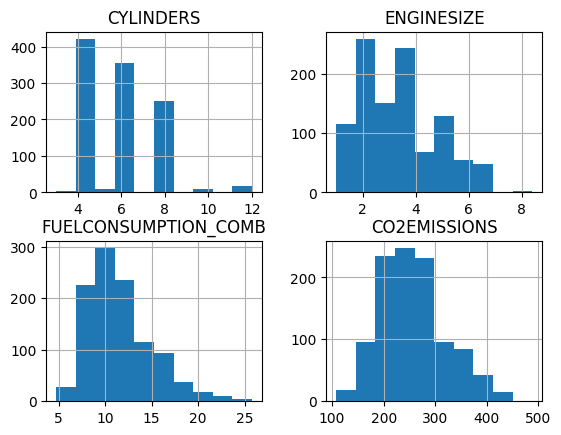

In [7]:
viz = cdf[['CYLINDERS','ENGINESIZE','FUELCONSUMPTION_COMB','CO2EMISSIONS']]
viz.hist()
plt.show()

As you can see, most engines have 4, 6, or 8 cylinders, and engine sizes between 2 and 4 liters.  
As you might expect, combined fuel consumption and CO2 emission have very similar distributions.  
Go ahead and display some scatter plots of these features against the CO2 emissions, to see how linear their relationships are.


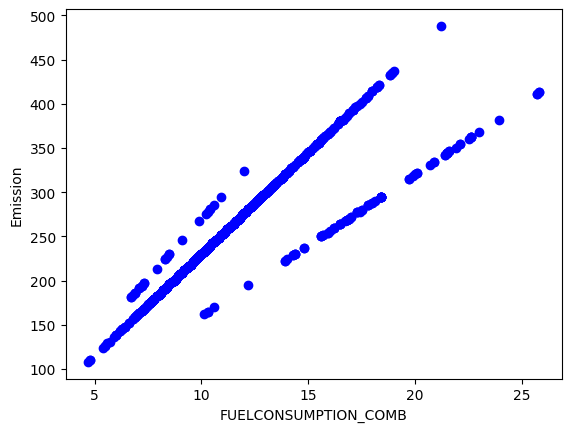

In [8]:
plt.scatter(cdf.FUELCONSUMPTION_COMB, cdf.CO2EMISSIONS,  color='blue')
plt.xlabel("FUELCONSUMPTION_COMB")
plt.ylabel("Emission")
plt.show()

This is an informative result. Three car groups each have a strong linear relationship between their combined fuel consumption and their CO2 emissions. 
Their intercepts are similar, while they noticeably differ in their slopes.


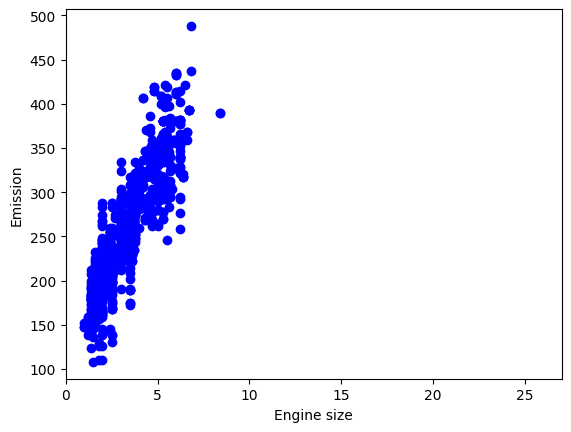

In [9]:
plt.scatter(cdf.ENGINESIZE, cdf.CO2EMISSIONS,  color='blue')
plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.xlim(0,27)
plt.show()

Although the relationship between engine size and CO2 emission is quite linear, you can see that their correlation is weaker than that for each of the three fuel consumption groups. Notice that the x-axis range has been expanded to make the two plots more comparable.


#### Practice excercise 1
Plot __CYLINDER__ against CO2 Emission, to see how linear their relationship is.


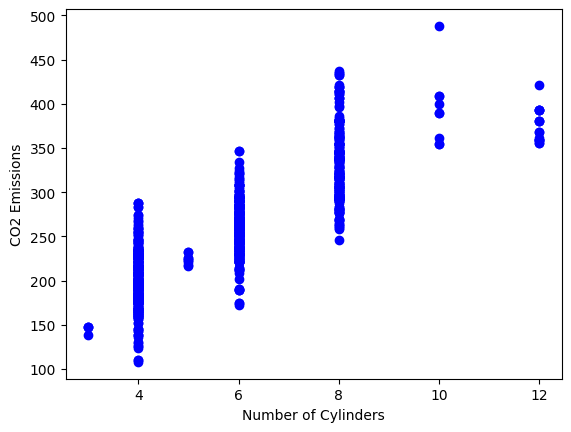

In [11]:
# write your code here
plt.scatter(
    x = cdf['CYLINDERS'],
    y = cdf['CO2EMISSIONS'],
    color='blue'
)
plt.xlabel('Number of Cylinders')
plt.ylabel('CO2 Emissions')
plt.show()

<details><summary>Click here for the solution</summary>

```python    
plt.scatter(cdf.CYLINDERS, cdf.CO2EMISSIONS,  color='blue')
plt.xlabel("CYLINDERS")
plt.ylabel("CO2 Emission")
plt.show()

```

</details>


### Extract the input feature and labels from the dataset
Although perhaps not necessarily the ideal choice of input feature, for illustration purposes, you will use engine size to predict CO2 emission with a linear regression model.  
You can begin the process by extracting the input feature and target output variables, X and y, from the dataset.


In [12]:
X = cdf.ENGINESIZE.to_numpy()
y = cdf.CO2EMISSIONS.to_numpy()

#### Create train and test datasets
Next, you will split the dataset into mutually exclusive training and testing sets. You will train a simple linear regression model on the training set and estimate its ability to generalize to unseen data by using it to make predictions on the unseen testing data. 

Since the outcome of each data point is part of the testing data, you have a means of evaluating the out-of-sample accuracy of your model.

Now, you want to randomly split your data into train and test sets, using 80% of the dataset for training and reserving the remaining 20% for testing. Which fraction to use here mostly depends on the size of your data, but typical testing sizes range from 20% to 30%. The smaller your data, the larger your training set needs to be because it's easier to find spurious patterns in smaller data. The downside is that your evaluation of generalizability will have less reliability. Bigger is better when it comes to data.


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

The outputs are one-dimensional NumPy arrays or vectors.


In [15]:
type(X_train), np.shape(X_train), np.shape(X_train)

(numpy.ndarray, (853,), (853,))

### Build a simple linear regression model

You'll use scikit-learn to build your model as follows. See [Scikit-Learn Linear Regression documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) to learn all about the linear model predictor object.


In [16]:
from sklearn import linear_model

# create a model object
regressor = linear_model.LinearRegression()

# train the model on the training data
# X_train is a 1-D array but sklearn models expect a 2D array as input for the training data, with shape (n_observations, n_features).
# So we need to reshape it. We can let it infer the number of observations using '-1'.
regressor.fit(X_train.reshape(-1, 1), y_train)

# Print the coefficients
print ('Coefficients: ', regressor.coef_[0]) # with simple linear regression there is only one coefficient, here we extract it from the 1 by 1 array.
print ('Intercept: ',regressor.intercept_)

Coefficients:  38.992978724434074
Intercept:  126.28970217408721


Here, __Coefficient__ and __Intercept__ are the regression parameters determined by the model.  
They define the slope and intercept of the 'best-fit' line to the training data. 


### Visualize model outputs


You can visualize the goodness-of-fit of the model to the training data by plotting the fitted line over the data.

The regression model is the line given by y = intercept + coefficient * x.


Text(0, 0.5, 'Emission')

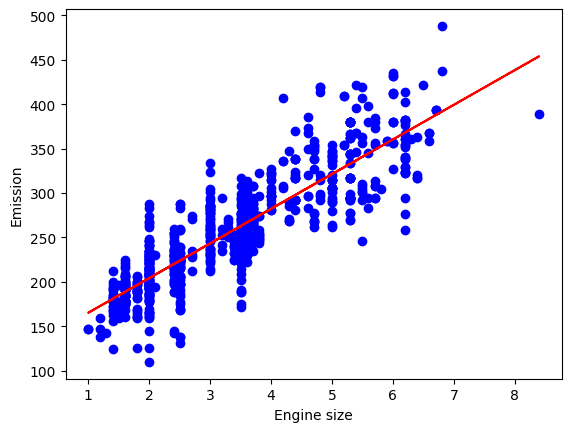

In [20]:
plt.scatter(X_train, y_train,  color='blue')
plt.plot(X_train, regressor.coef_ * X_train + regressor.intercept_, '-r')
plt.xlabel("Engine size")
plt.ylabel("Emission")

#### Model evaluation
You can compare the actual values and predicted values to calculate the accuracy of a regression model. Evaluation metrics play a key role in the development of a model, as they provide insight into areas that require improvement.

There are different model evaluation metrics, let's use MSE here to calculate the accuracy of our model based on the test set: 
* Mean Absolute Error: It is the mean of the absolute value of the errors. This is the easiest of the metrics to understand since it’s just an average error.

* Mean Squared Error (MSE): MSE is the mean of the squared error. In fact, it's the metric used by the model to find the best fit line, and for that reason, it is also called the residual sum of squares.

* Root Mean Squared Error (RMSE). RMSE simply transforms the MSE into the same units as the variables being compared, which can make it easier to interpret.

* R2-Score is not an error but rather a popular metric used to estimate the performance of your regression model. It represents how close the data points are to the fitted regression line. The higher the R2-Score value, the better the model fits your data. The best possible score is 1.0 and it can be negative (because the model can be arbitrarily worse).


In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Use the predict method to make test predictions
y_pred = regressor.predict(X_test.reshape(-1,1))

# Evaluation
print("Mean absolute error: %.2f" % mean_absolute_error(y_test, y_pred))
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
print("Root mean squared error: %.2f" % np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2-score: %.2f" % r2_score(y_test, y_pred))

Mean absolute error: 24.10
Mean squared error: 985.94
Root mean squared error: 31.40
R2-score: 0.76


## Practice exercises


#### 1. Plot the regression model result over the test data instead of the training data. Visually evaluate whether the result is good.


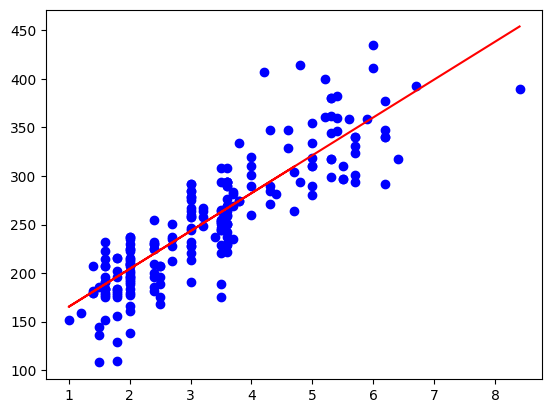

In [26]:
plt.scatter(X_test, y_test, color='blue')    #ADD CODE
plt.plot(X_test, regressor.intercept_ + X_test*regressor.coef_, color='red')
plt.show()

<details><summary>Click here for the solution</summary>

```python    
plt.scatter(X_test, y_test,  color='blue')
plt.plot(X_test, regressor.coef_ * X_test + regressor.intercept_, '-r')
plt.xlabel("Engine size")
plt.ylabel("Emission")
```

</details>


Let's see the evaluation metrics if you train a regression model using the `FUELCONSUMPTION_COMB` feature.

#### 2. Select the fuel consumption feature from the dataframe and split the data 80%/20% into training and testing sets. 
Use the same random state as previously so you can make an objective comparison to the previous training result.


In [44]:
X = cdf.FUELCONSUMPTION_COMB.to_numpy()  # ADD CODE


X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=11)#ADD CODE


<details><summary>Click here for the solution</summary>

```python    
X = cdf.FUELCONSUMPTION_COMB.to_numpy()
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
```

</details>


#### 3.  Train a linear regression model using the training data you created.
Remember to transform your 1D feature into a 2D array. 


In [45]:
regr = linear_model.LinearRegression() # ADD CODE

#ADD CODE
regr.fit(X_train.reshape(-1,1), y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


<details><summary>Click here for the solution</summary>

```python    
regr = linear_model.LinearRegression()
regr.fit(X_train.reshape(-1, 1), y_train)

```

</details>


#### 4. Use the model to make test predictions on the fuel consumption testing data.


In [46]:
y = regr.predict(X_test.reshape(-1,1))

<details><summary>Click here for the solution</summary>

```python    
y_pred= regr.predict(X_test.reshape(-1,1))

```

</details>


#### 5. Calculate and print the Mean Squared Error of the test predictions.


In [47]:
# ADD CODE
mean_squared_error(X_test.reshape(-1,1), y)

63614.098126117846

<details><summary>Click here for the solution</summary>

```python    
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
```

</details>


As you might expect from your exploratory analysis, the MSE is smaller when we train using `FUELCONSUMPTION_COMB` rather than `ENGINESIZE`.


### Congratulations! You're ready to move on to your next lesson.
 
 
## Author
<a href="https://www.linkedin.com/in/jpgrossman/" target="_blank">Jeff Grossman</a>  
 
 ### Other Contributors
 <a href="https://www.linkedin.com/in/abhishek-gagneja-23051987/" target="_blank">Abhishek Gagneja</a>

 ## <h3 align="center"> © IBM Corporation. All rights reserved. <h3/>

<!--
## Changelog
| Date | Version | Changed by | Change Description |
|------------|------|------------------|---------------------------------------|
| 2024-07-26 | 3.0  | Jeff Grossman    | Update content and practice exercises |
| 2020-11-03 | 2.1  | Lakshmi Holla    | Change URL of the csv |
| 2020-08-27 | 2.0  | Lavanya          | Move lab to course repo in GitLab |

